In [23]:
# Use Python 3.12.3

import pandas as pd
import numpy as np
import nfl_data_py as nfl
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

In [24]:
# seasons = range(2006, 2024)     #Passing stats started in 2006
pbp_py = nfl.import_pbp_data([2023])

2023 done.
Downcasting floats.


<h2>Cleaning Data</h2>

In [25]:
#Select relevant features
game_situation = ["yardline_100", "quarter_seconds_remaining", "half_seconds_remaining", "game_seconds_remaining", "drive", "qtr", "down", "ydstogo", "score_differential"] 
offensive = ["offense_formation", "offense_personnel"]
defensive = ["defenders_in_box", "defense_personnel"]
play_type = ["play_type", "run_location", "run_gap", "pass_location", "pass_length"]

df = pbp_py[game_situation + offensive + defensive + play_type]

# Drop plays that aren't run or pass plays
df = df.dropna(subset=["play_type"]).reset_index(drop=True)
df = df.loc[df['play_type'].isin(['run', 'pass'])]
len(df)

df_combined = df.copy()

# Put together offensive play call
def combine_columns(row):
    if row['play_type'] == 'run':
        return f"{row['play_type']}_{row['run_location']}_{row['run_gap']}"
    elif row['play_type'] == 'pass':
        return f"{row['play_type']}_{row['pass_location']}_{row['pass_length']}"
    else:
        return None

#Combine the necessary parts of the offensive play together
df_combined['offensive_play'] = df_combined.apply(combine_columns, axis=1)

# Remove plays that result in successful defensive stop
df_combined = df_combined[~df_combined['offensive_play'].isin(['pass_None_None', 'run_None_None', 'run_right_None', 'run_middle_None', 'run_left_None'])]
len(df_combined)

30000

From defensive perspective, predicting what the offense is going to run based on situational context (time remaining, downs, distance) and offensive formation

In [26]:
df_combined.groupby("offensive_play").count()

# Replace NaN with 0
df_combined = df_combined.fillna(0)
df_combined.head(10)

,yardline_100,quarter_seconds_remaining,half_seconds_remaining,game_seconds_remaining,drive,qtr,down,ydstogo,score_differential,offense_formation,offense_personnel,defenders_in_box,defense_personnel,play_type,run_location,run_gap,pass_location,pass_length,offensive_play
1,75.0,900.0,1800.0,3600.0,1.0,1.0,1.0,10.0,0.0,SHOTGUN,"1 RB, 2 TE, 2 WR",7.0,"3 DL, 4 LB, 4 DB",run,right,tackle,0,0,run_right_tackle
2,72.0,870.0,1770.0,3570.0,1.0,1.0,2.0,7.0,0.0,SHOTGUN,"1 RB, 1 TE, 3 WR",6.0,"2 DL, 4 LB, 5 DB",pass,0,0,right,short,pass_right_short
3,66.0,835.0,1735.0,3535.0,1.0,1.0,3.0,1.0,0.0,I_FORM,"1 RB, 1 TE, 3 WR",6.0,"2 DL, 4 LB, 5 DB",run,left,guard,0,0,run_left_guard
4,64.0,796.0,1696.0,3496.0,1.0,1.0,1.0,10.0,0.0,SHOTGUN,"1 RB, 1 TE, 3 WR",6.0,"3 DL, 3 LB, 5 DB",pass,0,0,middle,short,pass_middle_short
5,64.0,792.0,1692.0,3492.0,1.0,1.0,2.0,10.0,0.0,SINGLEBACK,"1 RB, 1 TE, 3 WR",6.0,"3 DL, 3 LB, 5 DB",pass,0,0,middle,short,pass_middle_short
6,52.0,754.0,1654.0,3454.0,1.0,1.0,1.0,10.0,0.0,SHOTGUN,"1 RB, 1 TE, 3 WR",6.0,"3 DL, 3 LB, 5 DB",pass,0,0,left,short,pass_left_short
7,51.0,716.0,1616.0,3416.0,1.0,1.0,2.0,9.0,0.0,SHOTGUN,"1 RB, 1 TE, 3 WR",6.0,"2 DL, 4 LB, 5 DB",pass,0,0,left,short,pass_left_short
8,51.0,711.0,1611.0,3411.0,1.0,1.0,3.0,9.0,0.0,SHOTGUN,"1 RB, 1 TE, 3 WR",6.0,"1 DL, 5 LB, 5 DB",pass,0,0,right,short,pass_right_short
10,83.0,659.0,1559.0,3359.0,2.0,1.0,1.0,10.0,0.0,SINGLEBACK,"1 RB, 1 TE, 3 WR",6.0,"4 DL, 2 LB, 5 DB",run,left,end,0,0,run_left_end
11,84.0,628.0,1528.0,3328.0,2.0,1.0,2.0,11.0,0.0,SINGLEBACK,"1 RB, 2 TE, 2 WR",7.0,"4 DL, 2 LB, 5 DB",run,left,guard,0,0,run_left_guard


In [27]:
df_combined.groupby(by="offensive_play").count()

,yardline_100,quarter_seconds_remaining,half_seconds_remaining,game_seconds_remaining,drive,qtr,down,ydstogo,score_differential,offense_formation,offense_personnel,defenders_in_box,defense_personnel,play_type,run_location,run_gap,pass_location,pass_length
offensive_play,,,,,,,,,,,,,,,,,,
pass_left_deep,1417,1417,1417,1417,1417,1417,1417,1417,1417,1417,1417,1417,1417,1417,1417,1417,1417,1417
pass_left_short,5994,5994,5994,5994,5994,5994,5994,5994,5994,5994,5994,5994,5994,5994,5994,5994,5994,5994
pass_middle_deep,621,621,621,621,621,621,621,621,621,621,621,621,621,621,621,621,621,621
pass_middle_short,3144,3144,3144,3144,3144,3144,3144,3144,3144,3144,3144,3144,3144,3144,3144,3144,3144,3144
pass_right_deep,1448,1448,1448,1448,1448,1448,1448,1448,1448,1448,1448,1448,1448,1448,1448,1448,1448,1448
pass_right_short,6560,6560,6560,6560,6560,6560,6560,6560,6560,6560,6560,6560,6560,6560,6560,6560,6560,6560
run_left_end,2048,2048,2048,2048,2048,2048,2048,2048,2048,2048,2048,2048,2048,2048,2048,2048,2048,2048
run_left_guard,1756,1756,1756,1756,1756,1756,1756,1756,1756,1756,1756,1756,1756,1756,1756,1756,1756,1756
run_left_tackle,1705,1705,1705,1705,1705,1705,1705,1705,1705,1705,1705,1705,1705,1705,1705,1705,1705,1705


In [28]:
X = pd.get_dummies(df_combined[game_situation + offensive + defensive])
y = df_combined["offensive_play"]

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_enc = le.fit_transform(y)

<h2>Neural Network Setup</h2>

In [29]:
import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader

# Create tensors
DEVICE        = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)
BATCH_SIZE    = 512
EPOCHS        = 25
LEARNING_RATE = 3e-4

X_train, X_test, y_train_enc, y_test_enc = train_test_split(
    X, y_enc,
    test_size=0.2,
    random_state=42,
    stratify=y_enc
)

X_train_t = torch.tensor(X_train.values, dtype=torch.float32)
X_test_t  = torch.tensor(X_test.values, dtype=torch.float32)
y_train_t = torch.tensor(y_train_enc, dtype=torch.long, device=DEVICE)
y_test_t  = torch.tensor(y_test_enc,  dtype=torch.long, device=DEVICE)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t),
                          batch_size=BATCH_SIZE, shuffle=True, drop_last=False)
test_loader  = DataLoader(TensorDataset(X_test_t,  y_test_t),
                          batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

# Define neural network model
class PlayClassifier(nn.Module):
    def __init__(self, in_features: int, n_classes: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_features, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.25),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.25),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, n_classes)
        )

    def forward(self, x):
        return self.net(x)

model = PlayClassifier(in_features=X_train.shape[1], n_classes=len(le.classes_)).to(DEVICE)

# Define loss function, optimizer, and learning rate scheduler
criterion  = nn.CrossEntropyLoss()
optimizer  = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
scheduler  = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=2, verbose=True)

# Train the model
def run_epoch(loader, train: bool):
    model.train(mode=train)
    total, correct, running_loss = 0, 0, 0.0

    context = torch.enable_grad() if train else torch.no_grad()
    with context:
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)

            logits = model(xb)
            loss   = criterion(logits, yb)

            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            running_loss += loss.item() * xb.size(0)
            preds        = logits.argmax(1)
            correct     += (preds == yb).sum().item()
            total       += xb.size(0)

    acc  = correct / total
    loss = running_loss / total
    return loss, acc

history = {"train_acc": [], "val_acc": []}

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = run_epoch(train_loader, train=True)
    val_loss, val_acc = run_epoch(test_loader,  train=False)
    scheduler.step(val_acc)

    history["train_acc"].append(tr_acc)
    history["val_acc"].append(val_acc)
    print(f"Epoch {epoch:02}/{EPOCHS} "
          f"| train acc: {tr_acc:6.3%} "
          f"| val acc: {val_acc:6.3%} "
          f"| val loss: {val_loss:8.4f}")

Device: cuda


e:\Anaconda\lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 01/25 | train acc: 18.496% | val acc: 21.883% | val loss:   2.2961
Epoch 02/25 | train acc: 21.625% | val acc: 21.450% | val loss:   2.2717
Epoch 03/25 | train acc: 21.179% | val acc: 21.767% | val loss:   2.2675
Epoch 04/25 | train acc: 21.133% | val acc: 21.867% | val loss:   2.2657
Epoch 05/25 | train acc: 21.433% | val acc: 21.983% | val loss:   2.2642
Epoch 06/25 | train acc: 21.629% | val acc: 21.900% | val loss:   2.2627
Epoch 07/25 | train acc: 21.838% | val acc: 21.900% | val loss:   2.2612
Epoch 08/25 | train acc: 21.333% | val acc: 21.933% | val loss:   2.2593
Epoch 09/25 | train acc: 21.583% | val acc: 21.917% | val loss:   2.2585
Epoch 10/25 | train acc: 21.408% | val acc: 22.033% | val loss:   2.2579
Epoch 11/25 | train acc: 21.554% | val acc: 22.067% | val loss:   2.2563
Epoch 12/25 | train acc: 21.454% | val acc: 22.083% | val loss:   2.2551
Epoch 13/25 | train acc: 21.575% | val acc: 22.050% | val loss:   2.2541
Epoch 14/25 | train acc: 21.504% | val acc: 21.983%

In [30]:
import torch, pandas as pd, numpy as np
from torch import nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from itertools import product
from collections import defaultdict

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

def make_loaders(batch_size=512, test_frac=0.2):
    X_train, X_test, y_tr, y_te = train_test_split(
        X, y_enc, test_size=test_frac, random_state=42, stratify=y_enc
    )
    X_train_t = torch.tensor(X_train.values, dtype=torch.float32)
    X_test_t  = torch.tensor(X_test.values,  dtype=torch.float32)
    y_train_t = torch.tensor(y_tr, dtype=torch.long)
    y_test_t  = torch.tensor(y_te, dtype=torch.long)

    train_loader = DataLoader(TensorDataset(X_train_t, y_train_t),
                              batch_size=batch_size, shuffle=True)
    test_loader  = DataLoader(TensorDataset(X_test_t,  y_test_t),
                              batch_size=batch_size, shuffle=False)
    return train_loader, test_loader, X_train.shape[1]

# Define the neural network model
class PlayClassifier(nn.Module):
    def __init__(self, in_features, n_classes, dropout=0.25, h1=256, h2=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_features, h1),
            nn.BatchNorm1d(h1),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(h1, h2),
            nn.BatchNorm1d(h2),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(h2, 64),
            nn.ReLU(),
            nn.Linear(64, n_classes)
        )

    def forward(self, x):
        return self.net(x)

# Train the model
def train_once(params):
    """
    params: dict with keys
        lr, batch_size, dropout, epochs
    Returns (history_df, best_val_acc)
    """
    epochs     = params["epochs"]
    lr         = params["lr"]
    dropout    = params["dropout"]
    batch_size = params["batch_size"]

    tl, vl, in_feats = make_loaders(batch_size=batch_size)
    model = PlayClassifier(in_features=in_feats,
                           n_classes=len(le.classes_),
                           dropout=dropout).to(DEVICE)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    sched     = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer,
                                                           mode="max", factor=0.5,
                                                           patience=2, verbose=False)

    def run_epoch(loader, train):
        model.train(train)
        total, correct, loss_sum = 0, 0, 0.
        with (torch.enable_grad() if train else torch.no_grad()):
            for xb, yb in loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                logits = model(xb)
                loss   = criterion(logits, yb)
                if train:
                    optimizer.zero_grad(); loss.backward(); optimizer.step()
                loss_sum += loss.item() * xb.size(0)
                correct  += (logits.argmax(1) == yb).sum().item()
                total    += xb.size(0)
        return loss_sum/total, correct/total

    hist = defaultdict(list)
    for ep in range(1, epochs+1):
        tr_loss, tr_acc = run_epoch(tl, True)
        vl_loss, vl_acc = run_epoch(vl, False)
        sched.step(vl_acc)

        hist["epoch"].append(ep)
        hist["train_acc"].append(tr_acc)
        hist["val_acc"].append(vl_acc)

    hist_df = pd.DataFrame(hist)
    return hist_df, hist_df["val_acc"].max()


Device: cuda


<h2>Neural Network Hyperparameter Search</h2>

In [31]:
grid = {
    "lr":         [3e-4, 1e-3],
    "batch_size": [256, 512],
    "dropout":    [0.25, 0.4],
    "epochs":     [20, 25],
}

experiments = list(product(*grid.values()))
key_names   = list(grid.keys())

# each item: (params_dict, hist_df, best_acc)
results = []

# Iterate over combinations of hyper-parameters
for combo in experiments:
    params = dict(zip(key_names, combo))
    print("Running:", params)
    hist_df, best = train_once(params)
    results.append((params, hist_df, best))
    print(f"   best val acc: {best:.3%}")

# Sort by best accuracy descending
results.sort(key=lambda tup: tup[2], reverse=True)


Running: {'lr': 0.0003, 'batch_size': 256, 'dropout': 0.25, 'epochs': 20}


e:\Anaconda\lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


   best val acc: 22.450%
Running: {'lr': 0.0003, 'batch_size': 256, 'dropout': 0.25, 'epochs': 25}


e:\Anaconda\lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


   best val acc: 22.250%
Running: {'lr': 0.0003, 'batch_size': 256, 'dropout': 0.4, 'epochs': 20}


...

   best val acc: 22.883%
Running: {'lr': 0.001, 'batch_size': 512, 'dropout': 0.4, 'epochs': 20}


e:\Anaconda\lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


   best val acc: 22.233%
Running: {'lr': 0.001, 'batch_size': 512, 'dropout': 0.4, 'epochs': 25}


e:\Anaconda\lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


   best val acc: 21.983%


<h2>Plot Results</h2>

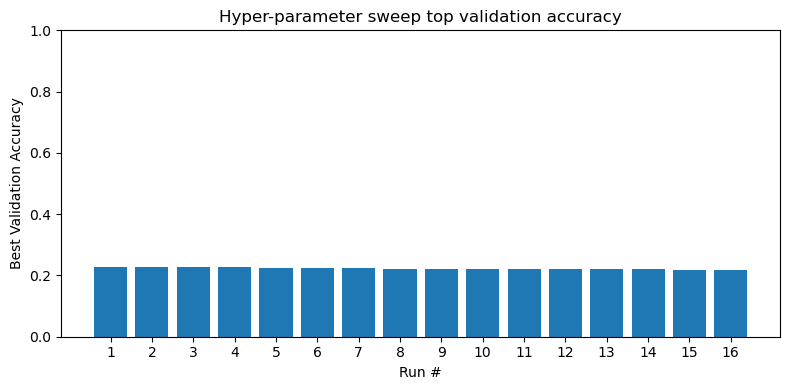

,run,lr,batch_size,dropout,epochs,best_val_acc
0,1,0.0010,512,0.25,25,0.228833
1,2,0.0010,256,0.25,20,0.226833
2,3,0.0010,256,0.40,25,0.226833
3,4,0.0010,256,0.25,25,0.226333
4,5,0.0010,512,0.25,20,0.225833
5,6,0.0010,256,0.40,20,0.225000
6,7,0.0003,256,0.25,20,0.224500
7,8,0.0003,256,0.25,25,0.222500
8,9,0.0003,256,0.40,20,0.222333
9,10,0.0010,512,0.40,20,0.222333


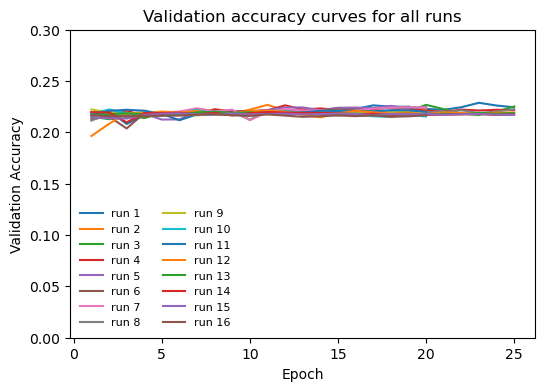

Best params: {'lr': 0.001, 'batch_size': 512, 'dropout': 0.25, 'epochs': 25}


In [32]:
import matplotlib.pyplot as plt

# summary chart of best validation accuracy
summary = (
    pd.DataFrame(
        [{"run": i+1, **p, "best_val_acc": acc} for i, (p, _, acc) in enumerate(results)]
    )
    .sort_values("best_val_acc", ascending=False)
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(8, 4))

ax.bar(summary.index, summary["best_val_acc"])
ax.set_ylim(0, 1)
ax.set_ylabel("Best Validation Accuracy")
ax.set_xlabel("Run #")

# show run number on x-axis
ax.set_xticks(summary.index, summary["run"])
ax.set_title("Hyper-parameter sweep top validation accuracy")

plt.tight_layout()
plt.show()

# table of the runs and params
display(summary[["run", "lr", "batch_size", "dropout", "epochs", "best_val_acc"]])

# validation-accuracy curves for all runs
plt.figure(figsize=(6, 4))
for i, (_, hist_df, _) in enumerate(results, 1):
    plt.plot(hist_df["epoch"], hist_df["val_acc"], label=f"run {i}")

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.ylim(0, 0.3)
plt.title("Validation accuracy curves for all runs")
plt.legend(ncol=2, fontsize=8, frameon=False)
# plt.tight_layout()
plt.show()

# print the best hyper-parameters
best_params = results[0][0]
print("Best params:", best_params)


<h2>Calculating Accuracy for Multiple Guesses</h2>

,k,top_k_acc
0,1,0.221667
1,2,0.418500
2,3,0.526667
3,4,0.595500
4,5,0.662333
5,6,0.725667
6,7,0.789667
7,8,0.849333
8,9,0.899000
9,10,0.940833


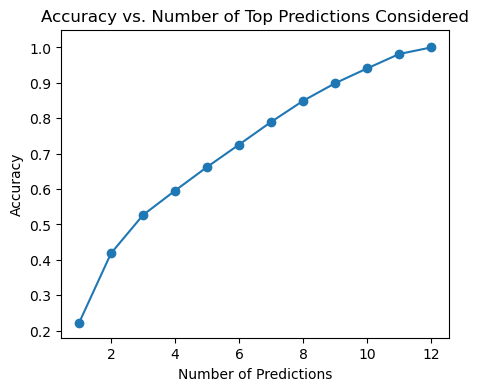

In [33]:
import torch, pandas as pd, matplotlib.pyplot as plt

max_k = 12
model.eval()
all_correct_at_k = torch.zeros(max_k, dtype=torch.long)
total_samples    = 0

with torch.no_grad():
    for xb, yb in test_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        logits = model(xb)
        # sort scores descending
        topk = logits.topk(max_k, dim=1).indices          # shape [batch, max_k]
        # Compare each row's true label with its top predictions using boolean mask
        correct = topk.eq(yb.view(-1, 1))
        # cumulative correctness
        correct_cumsum = correct.cumsum(dim=1) > 0        
        all_correct_at_k += correct_cumsum.sum(dim=0).cpu()
        total_samples    += xb.size(0)

# Build a DataFrame with accuracies
acc_dict = {"k": [], "top_k_acc": []}
for k in range(1, max_k + 1):
    acc = all_correct_at_k[k-1].item() / total_samples
    acc_dict["k"].append(k)
    acc_dict["top_k_acc"].append(acc)

topk_df = pd.DataFrame(acc_dict)
display(topk_df)

# Plot
plt.figure(figsize=(5, 4))
plt.plot(topk_df["k"], topk_df["top_k_acc"], marker="o")
plt.xlabel("Number of Predictions")
plt.ylabel("Accuracy")
plt.ylim(.18, 1.05)
plt.title("Accuracy vs. Number of Top Predictions Considered")
plt.show()